# Brain-as-LLM Local Linearization Experiment

**Goal:** test whether human intracranial neural population dynamics can be treated, locally, like hidden-state dynamics in an LLM:

$$\hat{x}_{t+\Delta} = A\,x_t + b + \hat{w}_t$$

| LLM | Brain |
|---|---|
| hidden state $h[l,t]$ | population state $x[l,t]$ |
| layer $l$ | anatomical module (temporal cortex → entorhinal → hippocampus) |
| hidden-state dimension | electrode **channel** (never "neuron") |
| token index | 20-ms time bin |

**Story:** locally linearizable → finite temporal prediction horizon → degradation under state shift (placebo → scopolamine OOD).

Full specification: [ANALYSIS_SPEC.md](ANALYSIS_SPEC.md)

**Guardrails (from spec):**
- Fit dynamics **within patient** only; aggregate statistics across patients (patient = inferential unit).
- Split by **whole trials**, never individual time points; all preprocessing/hyperparameters from training data only.
- Residual model $\hat{w}_t = g(x_t)$ trained on **training residuals** — never add back test residuals.
- OOD evaluation uses the **frozen** model (same $A$, $b$, $g$, normalization).
- Report negative results honestly (spec §28).

## Dataset: Basu et al., *Nature BME* 2023 (closed-loop cognitive control)

**Paper:** "Closed-loop enhancement and neural decoding of cognitive control in humans" (doi:10.1038/s41551-021-00804-y) — [StimPaper.pdf](StimPaper.pdf).

Actual dataset properties (these override the spec's placeholder assumptions):

| Spec assumption | Actual dataset |
|---|---|
| Memory encoding task | **MSIT** conflict task, trials aligned to image onset |
| Placebo vs scopolamine | **Stimulation state**: NS1 (no-stim blocks) vs NS2 (non-stim trials in stim blocks) vs stimulated trials (130 Hz internal-capsule/striatal stim, 600 ms at image onset, 2–4 mA) |
| 1000 Hz native | Recorded 2 kHz → **decimated to 1000 Hz**, bipolar re-referenced, 60 Hz + harmonics removed, IED channels rejected |
| Temporal ctx → entorhinal → hippocampus | 16 regions incl. **PFC subdivisions, cingulate, OFC, temporal, insula, amygdala, hippocampus, NAcc, caudate** — layer hierarchy to be redefined on actual coverage |
| −500..+1500 ms epoch | Paper analyzes 0.1–1.4 s post-image (decision period); baseline −0.5..0 s. Trials cut with 2 s buffers |
| Bands 2–4…32–64 Hz | Paper bands: 4–8, 8–15, 15–30, 30–55, 65–110, 135–200 Hz (Morlet, 10 ms steps; high gamma split around the 130 Hz stim frequency) |

**OOD design (adapted):** train on **NS1** trials → test-ID: held-out NS1 → test-OOD: **NS2** (behavioral/physiological state shift without stim artifact). Stimulated trials are a stronger shift but artifact-contaminated — treat separately and exclude the 600-ms stim window or use post-stim segments.

**Files:**
- `Behavior_Stim_Subjects.mat` — 3224 trials, 9 subjects (P8–P15, P17): `subject, blockNum, trialNum, interference` (conflict 0/1), `responseTimes, responseCorrect, StimAny` (0/1), `trialStim`/`blockStim` (site labels: None, L/R DS, L/R VS, L Mid, CL variants).
- `BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat` — FieldTrip-format bipolar LFP epochs aligned to image onset, patient P12, stim session 1 (MATLAB v7.3/HDF5, ~2.7 GB; per-patient files expected).


## 0. Configuration

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Paths (DATA_DIR to be pointed at the provided data folder) ----
HERE = Path.cwd() if (Path.cwd() / "ANALYSIS_SPEC.md").exists() else Path("NeuroAnalysis")
DATA_DIR = HERE / "data"          # <- point to the provided data folder
RESULTS_DIR = HERE / "results"
PRED_DIR = HERE / "predictions"
FIG_DIR = HERE / "figures"
for d in (RESULTS_DIR, PRED_DIR, FIG_DIR):
    d.mkdir(parents=True, exist_ok=True)

# ---- Signal parameters (spec §2, §4, §5) ----
FS = 1000                          # native sampling rate (Hz)
EPOCH_MS = (-500, 1500)            # baseline: -500..0, encoding: 0..1500
BANDS = {
    "slow_theta": (2, 4),
    "theta": (4, 8),
    "alpha": (8, 16),
    "beta": (16, 32),
    "gamma": (32, 64),
}
PRIMARY_BAND = "theta"
TOKEN_STRIDE_MS = 20               # brain "token" spacing
CAUSAL_WINDOW_MS = 40              # x(t) = mean power over [t-40ms, t] (no future leakage)

# ---- Horizons (spec §6) ----
PRIMARY_HORIZON_MS = 20
HORIZONS_MS = [10, 20, 50, 100, 200]

# ---- Splits (spec §8): by whole trials ----
SPLIT_FRACS = (0.6, 0.2, 0.2)      # train / val / test
RANDOM_SEED = 0

# ---- Anatomical layers (spec §3) ----
LAYERS = ["temporal_cortex", "entorhinal", "hippocampus"]

# ---- Figure colors (spec §23): identical across all panels ----
COLOR_TRUE = "black"
COLOR_LINEAR = "#1f4ea1"          # blue: A x_t
COLOR_RESIDUAL = "#c1272d"        # red:  A x_t + w_hat
COLOR_ID = "#7f9fbf"              # muted: placebo / ID
COLOR_OOD = "#bf8f7f"             # muted: scopolamine / OOD

rng = np.random.default_rng(RANDOM_SEED)
print(f"DATA_DIR = {DATA_DIR.resolve()}  (exists: {DATA_DIR.exists()})")

DATA_DIR = /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/data  (exists: False)


## 1. Load & validate data (STEP 1)

Load electrode localization + trial metadata. Validate:
- patients, sessions, trial counts per condition (placebo / scopolamine; FR / AR)
- electrode counts per region per patient (simultaneous coverage map)
- epoch alignment (-500..+1500 ms @ 1000 Hz)

*Awaiting data folder — loader will be implemented against the actual file format.*

In [7]:
import re

import h5py
import scipy.io as sio

# ---------- Behavior (all subjects) ----------
beh_raw = sio.loadmat(HERE / "Behavior_Stim_Subjects.mat", squeeze_me=True)
trial_metadata = pd.DataFrame(
    {k: beh_raw[k] for k in
     ["subject", "blockNum", "trialNum", "interference", "responseTimes",
      "responseCorrect", "StimAny", "trialStim", "blockStim"]}
)
for col in ("subject", "trialStim", "blockStim"):
    trial_metadata[col] = trial_metadata[col].astype(str)

# Trial taxonomy for the OOD design (paper's NS1/NS2 definitions):
#   NS1 = trials in blocks with no stimulation at all      -> train + ID test
#   NS2 = non-stimulated trials inside stimulation blocks  -> OOD test
#   STIM = stimulated trials (130 Hz artifact)             -> handled separately
def classify_trial(row):
    if row["blockStim"] in ("None", "NoneCL"):
        return "NS1"
    if row["trialStim"] == "None":
        return "NS2"
    return "STIM"

trial_metadata["condition"] = trial_metadata.apply(classify_trial, axis=1)
print("trials per subject x condition:")
print(trial_metadata.groupby(["subject", "condition"]).size().unstack(fill_value=0))


# ---------- Neural data loader (schema of BIPOLFieldTripFormat_* files) ----------
# Root variables (MATLAB v7.3 / HDF5):
#   ft_data3                 FieldTrip struct: fsample=1000, label (151 ch),
#                            trial = 127 x (6000 samples x 151 ch), time = -2..4 s
#   TrialDet (36 x n_trials) per-trial metadata; headers in TrialDetHeaders
#                            (incl. Conflict, Stimulation, Correct, ResponseTime)
#   ChannelPairNamesBank1/2  bipolar pair names (99 + 52 = 151)
#   ParcellationValues       (8 x 151) per channel: parc4-6 look like MNI x/y/z,
#                            parc7 a parcel label, parc0-3 tissue probabilities
#   ch_ictal                 char matrix of PAIR NAMES with interictal discharges -> exclude
#   stim                     session-level stim flag

def _rs(f, ref_or_ds):
    """Read a MATLAB string stored as uint16 codes (possibly via object ref)."""
    ds = f[ref_or_ds] if isinstance(ref_or_ds, h5py.Reference) else ref_or_ds
    return "".join(chr(int(c)) for c in np.array(ds).ravel())


def _read_string_list(f, ds):
    return [_rs(f, r) for r in np.array(ds).ravel()]


def _read_char_matrix(arr):
    """(len x n) uint16 char matrix -> list of n strings."""
    return ["".join(chr(c) for c in arr[:, i] if c) for i in range(arr.shape[1])]


def load_session(path):
    """Load one BIPOLFieldTripFormat session file.

    Returns dict:
        data      (n_trials, n_channels, n_samples) float32, image onset at t=0
        time      (n_samples,) seconds
        fs        sampling rate
        trials    DataFrame from TrialDet (one row per FT trial)
        channels  DataFrame [pair_name, bank, ictal flag, parc columns]
        ictal     list of pair NAMES flagged with interictal discharges
    """
    f = h5py.File(path, "r")
    ft = f["ft_data3"]
    fs = float(np.array(ft["fsample"]).squeeze())

    trial_refs = np.array(ft["trial"]).ravel()
    trials_raw = [np.array(f[r], dtype=np.float32) for r in trial_refs]
    # HDF5 layout: (n_samples, n_channels) -> transpose
    n_ch = len(np.array(ft["label"]).ravel())
    trials_raw = [t.T if t.shape[1] == n_ch else t for t in trials_raw]
    min_len = min(t.shape[1] for t in trials_raw)
    data = np.stack([t[:, :min_len] for t in trials_raw])
    time = np.array(f[np.array(ft["time"]).ravel()[0]]).ravel()[:min_len]

    # Per-trial metadata
    tdh = _read_string_list(f, f["TrialDetHeaders"])
    trials = pd.DataFrame(np.array(f["TrialDet"]).T, columns=tdh)

    # Channel names: bank1 + bank2 bipolar pair names
    names = (_read_char_matrix(np.array(f["ChannelPairNamesBank1"]))
             + _read_char_matrix(np.array(f["ChannelPairNamesBank2"])))
    banks = [1] * np.array(f["ChannelPairNamesBank1"]).shape[1] \
          + [2] * np.array(f["ChannelPairNamesBank2"]).shape[1]
    channels = pd.DataFrame({"pair_name": names, "bank": banks})
    parc = np.array(f["ParcellationValues"])          # (8, n_ch)
    for i in range(parc.shape[0]):
        channels[f"parc{i}"] = parc[i, :len(channels)]

    ictal = _read_char_matrix(np.array(f["ch_ictal"]))   # pair names, e.g. 'LAF10 LAF11'
    channels["ictal"] = channels["pair_name"].isin(ictal)
    stim_flag = float(np.array(f["stim"]).squeeze())
    f.close()

    assert data.shape[1] == len(channels), (data.shape, len(channels))
    return {"data": data, "time": time, "fs": fs, "trials": trials,
            "channels": channels, "ictal": ictal, "stim_flag": stim_flag}


NEURAL_FILES = sorted(HERE.glob("BIPOLFieldTripFormat_AlignedToImagePresent_*.mat"))
print("\nneural files found:")
for p in NEURAL_FILES:
    m = re.search(r"_(P\d+)_(\w+)\.mat$", p.name)
    print(f"  {p.name}  ->  patient={m.group(1)}  session={m.group(2)}  ({p.stat().st_size/1e9:.2f} GB)")


trials per subject x condition:
condition  NS1  NS2  STIM
subject                  
P10        128   96    96
P11        128   61   194
P12        159  110   114
P13        191  124   125
P14        185  192     0
P15        128  127     0
P17        126  219     0
P8         110  114   119
P9         124  128   126

neural files found:
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim1.mat  ->  patient=P12  session=NoStim1  (0.98 GB)
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim2.mat  ->  patient=P12  session=NoStim2  (0.89 GB)
  BIPOLFieldTripFormat_AlignedToImagePresent_P12_Stim1.mat  ->  patient=P12  session=Stim1  (1.88 GB)


In [8]:
# --- Validate the loader on the first complete session file (P12 NoStim2) ---
sess = load_session(HERE / "BIPOLFieldTripFormat_AlignedToImagePresent_P12_NoStim2.mat")

print(f"fs             : {sess['fs']}")
print(f"data shape     : {sess['data'].shape}  (trials, channels, samples)")
print(f"time axis      : {sess['time'][0]:.3f} .. {sess['time'][-1]:.3f} s, n={len(sess['time'])}")
print(f"n channel pairs: {len(sess['channels'])}  ({sess['channels']['ictal'].sum()} flagged ictal -> excluded)")
print(f"stim flag      : {sess['stim_flag']}")

# electrode groups by lead prefix (e.g. LAF = left anterior frontal lead)
sess["channels"]["lead"] = sess["channels"]["pair_name"].str.extract(r"^([A-Za-z]+)")
print("\nchannel pairs per lead (clean/total):")
grp = sess["channels"].groupby("lead").agg(total=("pair_name", "size"), clean=("ictal", lambda s: (~s).sum()))
print(grp.T.to_string())

display(sess["channels"].head(8))

# TrialDet sanity vs behavior table
td = sess["trials"]
print(f"\nTrialDet shape: {td.shape}")
for c in ["Conflict", "Stimulation", "Correct"]:
    print(f"  {c}: {td[c].value_counts().to_dict()}")
p12 = trial_metadata[trial_metadata.subject == "P12"]
print(f"\nBehavior file P12: NS1={len(p12[p12.condition=='NS1'])}, NS2={len(p12[p12.condition=='NS2'])}, "
      f"STIM={len(p12[p12.condition=='STIM'])}  |  this session (NoStim2): {len(td)} trials, all Stimulation=0")


fs             : 1000.0
data shape     : (127, 151, 6000)  (trials, channels, samples)
time axis      : -1.999 .. 4.000 s, n=6000
n channel pairs: 151  (37 flagged ictal -> excluded)
stim flag      : 0.0

channel pairs per lead (clean/total):
lead   LAF  LAI  LAO  LMF  LOF  LPF  LPO  LPT  LVF  RAF  RAT  RMF  RMT  RVF
total   11   11   15   13   13   13    9    8   15   11    8    5   10    9
clean    9   11    8    4    0   13    8    5   15   11    8    5    8    9


,pair_name,bank,parc0,parc1,parc2,parc3,parc4,parc5,parc6,parc7,ictal,lead
0,LAF03 LAF04,1,1.0,0.015789,0.984212,-4.132497,-22.0,17.0,52.0,2.0,False,LAF
1,LAF04 LAF05,1,1.0,0.041825,0.958176,-3.131535,-26.0,16.0,52.0,1.0,False,LAF
2,LAF05 LAF06,1,1.0,0.121076,0.878925,-1.982279,-29.5,15.0,52.0,1.0,False,LAF
3,LAF06 LAF07,1,1.0,0.156780,0.843221,-1.682388,-32.5,14.5,52.0,1.0,False,LAF
4,LAF07 LAF08,1,1.0,0.073171,0.926830,-2.538975,-36.5,15.0,51.5,1.0,False,LAF
5,LAF08 LAF09,1,1.0,0.081218,0.918783,-2.425909,-40.5,14.0,51.0,1.0,False,LAF
6,LAF09 LAF10,1,1.0,0.133333,0.866668,-1.871803,-44.0,13.0,50.5,1.0,False,LAF
7,LAF10 LAF11,1,1.0,0.404494,0.595507,-0.386775,-47.0,13.0,50.0,1.0,True,LAF



TrialDet shape: (127, 36)
  Conflict: {0.0: 32, 1.0: 32, 2.0: 32, 3.0: 31}
  Stimulation: {0.0: 127}
  Correct: {3.0: 48, 1.0: 42, 2.0: 37}

Behavior file P12: NS1=159, NS2=110, STIM=114  |  this session (NoStim2): 127 trials, all Stimulation=0


In [14]:
# --- Cache loaded sessions to local npz (uploads are unstable and get overwritten) ---
CACHE_DIR = HERE / "cache"
CACHE_DIR.mkdir(exist_ok=True)

def cache_session(sess, name):
    out = CACHE_DIR / f"{name}.npz"
    np.savez_compressed(
        out, data=sess["data"], time=sess["time"], fs=sess["fs"],
        trials_csv=sess["trials"].to_csv(index=False),
        channels_csv=sess["channels"].to_csv(index=False),
        stim_flag=sess["stim_flag"])
    print(f"cached -> {out} ({out.stat().st_size/1e9:.2f} GB)")

def load_cached(name):
    import io
    f = np.load(CACHE_DIR / f"{name}.npz", allow_pickle=False)
    return {"data": f["data"], "time": f["time"], "fs": float(f["fs"]),
            "trials": pd.read_csv(io.StringIO(str(f["trials_csv"]))),
            "channels": pd.read_csv(io.StringIO(str(f["channels_csv"]))),
            "stim_flag": float(f["stim_flag"])}

if not (CACHE_DIR / "P12_NoStim2.npz").exists():
    cache_session(sess, "P12_NoStim2")


cached -> /teamspace/studios/this_studio/LinearLLMDynamic/NeuroAnalysis/cache/P12_NoStim2.npz (0.43 GB)


## 2. Preprocessing → band-power state (STEPS 2-3)

Per electrode & band: baseline-normalized Hilbert power; causal token features
$x(t) = \text{mean power over } [t-40\,\text{ms}, t]$ at 20-ms stride → per-patient, per-region state matrices `(n_trials, n_tokens, n_channels)`.

In [9]:
from scipy.signal import butter, sosfiltfilt, hilbert

# NOTE (spec §5): sosfiltfilt is zero-phase and therefore ACAUSAL. We keep it for the
# main analysis (standard practice for band power) and note that a causal-filter
# sensitivity analysis is a robustness check, not part of the primary pipeline.

def band_power(data, fs, band):
    """Bandpass -> Hilbert envelope power.

    data: (n_trials, n_channels, n_samples) -> power, same shape.
    """
    lo, hi = BANDS[band]
    sos = butter(4, [lo, hi], btype="bandpass", fs=fs, output="sos")
    filt = sosfiltfilt(sos, data, axis=-1)
    # pad to next fast length would be ideal; 6000 samples is fine for hilbert
    return np.abs(hilbert(filt, axis=-1)).astype(np.float32) ** 2


def tokenize(power, time):
    """Causal tokens: mean power over [t-40ms, t], 20-ms stride, t in [0, 1500] ms.

    Returns
        tokens   (n_trials, n_tokens, n_channels)
        baseline (n_trials, n_channels) mean power over [-500, 0) ms
        token_t  (n_tokens,) token times in ms
    """
    t_ms = time * 1000.0
    token_t = np.arange(CAUSAL_WINDOW_MS, EPOCH_MS[1] + 1, TOKEN_STRIDE_MS, dtype=float)
    toks = []
    for t in token_t:
        m = (t_ms > t - CAUSAL_WINDOW_MS) & (t_ms <= t)
        toks.append(power[:, :, m].mean(axis=-1))
    tokens = np.stack(toks, axis=1)                                   # (trials, tokens, ch)
    base_m = (t_ms >= EPOCH_MS[0]) & (t_ms < 0)
    baseline = power[:, :, base_m].mean(axis=-1)                      # (trials, ch)
    return tokens, baseline, token_t


def normalize_tokens(tokens, baseline, train_idx):
    """Baseline z-normalization with TRAINING-trial statistics only (spec §3, §14).

    Per channel: (tokens - mean_train_baseline) / std_train_baseline.
    Same transform applied to every split / condition (frozen for OOD).
    """
    mu = baseline[train_idx].mean(axis=0)                             # (ch,)
    sd = baseline[train_idx].std(axis=0) + 1e-12
    return (tokens - mu[None, None, :]) / sd[None, None, :]


# --- Validate on P12 NoStim2, theta, clean channels ---
clean_idx = np.flatnonzero(~sess["channels"]["ictal"].to_numpy())
pw = band_power(sess["data"][:, clean_idx, :], sess["fs"], PRIMARY_BAND)
tokens, baseline, token_t = tokenize(pw, sess["time"])
print(f"clean channels : {len(clean_idx)}")
print(f"power          : {pw.shape}")
print(f"tokens         : {tokens.shape}  (trials, tokens, channels), token times {token_t[0]:.0f}..{token_t[-1]:.0f} ms")
_demo_train = np.arange(len(tokens))  # placeholder: real split in Section 3
z = normalize_tokens(tokens, baseline, _demo_train)
print(f"normalized     : mean={z.mean():.3f}, std={z.std():.3f} (task-evoked power > baseline expected)")


clean channels : 114
power          : (127, 114, 6000)
tokens         : (127, 74, 114)  (trials, tokens, channels), token times 40..1500 ms
normalized     : mean=0.050, std=1.502 (task-evoked power > baseline expected)


## 3. Trial-wise splits (STEP 4)

Group by `trial_id` (session-aware if sessions exist): 60/20/20 train/val/test. No time-point-level splitting.

In [10]:
def trial_split(n_trials, fracs=SPLIT_FRACS, seed=RANDOM_SEED):
    """Whole-trial 60/20/20 split (spec §6: NEVER split within trials)."""
    rng_ = np.random.default_rng(seed)
    order = rng_.permutation(n_trials)
    n_tr = int(round(fracs[0] * n_trials))
    n_va = int(round(fracs[1] * n_trials))
    return order[:n_tr], order[n_tr:n_tr + n_va], order[n_tr + n_va:]


tr, va, te = trial_split(tokens.shape[0])
print(f"split (NoStim2, {tokens.shape[0]} trials): train={len(tr)}, val={len(va)}, test={len(te)}")
assert not (set(tr) & set(va)) and not (set(tr) & set(te)) and not (set(va) & set(te))


split (NoStim2, 127 trials): train=76, val=25, test=26


## 4. Models & baselines (STEPS 5-6, 8)

- **Persistence:** $\hat{x}_{t+\Delta} = x_t$
- **Mean trajectory:** $\hat{x}_{t+\Delta} = \mu(t+\Delta)$ (training condition mean)
- **Diagonal AR** (optional): each channel predicts itself
- **Ridge linear:** $\hat{x}_{t+\Delta} = A x_t + b$, $\lambda$ chosen on training/validation only
- **Residual model:** $\hat{w}_t = g(x_t)$, low-capacity MLP $N \to \min(32, 2N) \to N$ (or kernel ridge for small $N$), trained on *training residuals*, early stopping on validation

Metrics (spec §11-12): population $R^2$ (primary), NRMSE, Pearson r, cosine similarity, relative residual energy, $\Delta R^2$.

In [11]:
import torch
import torch.nn as tnn

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def make_pairs(z, h_steps):
    """Within-trial (x_t, x_{t+h}) pairs. z: (trials, tokens, ch) -> X, Y: (pairs, ch)."""
    X = z[:, :-h_steps, :].reshape(-1, z.shape[-1])
    Y = z[:, h_steps:, :].reshape(-1, z.shape[-1])
    return X, Y


def fit_ridge(Xtr, Ytr, Xva, Yva, lambdas=(1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)):
    """x_{t+h} = A x_t + b, closed form; lambda chosen on validation R^2 only (spec §7)."""
    Xa = np.hstack([Xtr, np.ones((len(Xtr), 1))])                    # intercept via augmentation
    XtX, XtY = Xa.T @ Xa, Xa.T @ Ytr
    eye = np.eye(Xa.shape[1]); eye[-1, -1] = 0                       # don't penalize b
    best = None
    for lam in lambdas:
        W = np.linalg.solve(XtX + lam * eye, XtY)                    # (ch+1, ch)
        r2 = pop_r2(Yva, np.hstack([Xva, np.ones((len(Xva), 1))]) @ W)
        if best is None or r2 > best[1]:
            best = (W, r2, lam)
    W, _, lam = best
    A, b = W[:-1].T, W[-1]
    return A, b, lam


def ridge_predict(A, b, X):
    return X @ A.T + b


class ResidualMLP(tnn.Module):
    """w_hat = g(x_t): N -> min(32, 2N) -> N (spec §8, low capacity)."""
    def __init__(self, n):
        super().__init__()
        h = min(32, 2 * n)
        self.net = tnn.Sequential(tnn.Linear(n, h), tnn.ReLU(), tnn.Linear(h, n))

    def forward(self, x):
        return self.net(x)


def fit_residual_mlp(Xtr, Rtr, Xva, Rva, epochs=500, patience=25, seed=RANDOM_SEED):
    """Train g on TRAINING residuals only; early stopping on validation residuals."""
    torch.manual_seed(seed)
    model = ResidualMLP(Xtr.shape[1]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    xt, rt = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xtr, Rtr))
    xv, rv = (torch.as_tensor(a, dtype=torch.float32, device=DEVICE) for a in (Xva, Rva))
    best_state, best_val, bad = None, np.inf, 0
    for _ in range(epochs):
        model.train(); opt.zero_grad()
        loss = tnn.functional.mse_loss(model(xt), rt)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            val = tnn.functional.mse_loss(model(xv), rv).item()
        if val < best_val - 1e-6:
            best_val, bad = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    model.load_state_dict(best_state)
    model.eval()
    return model


def mlp_predict(model, X):
    with torch.no_grad():
        return model(torch.as_tensor(X, dtype=torch.float32, device=DEVICE)).cpu().numpy()


# ---------- Metrics (spec §11-12) ----------
def pop_r2(Y, Yhat):
    """Population R^2: 1 - SSE / total variance of Y."""
    return 1.0 - ((Y - Yhat) ** 2).sum() / ((Y - Y.mean(axis=0)) ** 2).sum()

def nrmse(Y, Yhat):
    return np.sqrt(((Y - Yhat) ** 2).mean()) / (Y.std() + 1e-12)

def resid_energy(Y, Yhat):
    """Relative residual energy: ||Y - Yhat||^2 / ||Y||^2."""
    return ((Y - Yhat) ** 2).sum() / ((Y ** 2).sum() + 1e-12)

def eval_all(Y, Yhat):
    return {"R2": pop_r2(Y, Yhat), "NRMSE": nrmse(Y, Yhat), "resid_energy": resid_energy(Y, Yhat)}

print(f"models ready (device={DEVICE})")


models ready (device=cpu)


## 5. Proof of concept (spec §27, adapted to this dataset)

Spec asked for hippocampus, but P12 has **no hippocampal lead** — coverage is prefrontal/frontal
(best clean coverage: LVF ×15, LPF ×13). Adapted POC: **P12 · LVF lead · theta 4-8 Hz · 0-1500 ms ·
stride 20 ms · Δ = 20 ms**.

Outputs: true-vs-predicted trajectory; $R^2$ for persistence / $Ax$ / $Ax+\hat{w}$; residual-energy ratio;
**NS1-ID vs NS2-OOD** comparison (replaces placebo/scopolamine; frozen model).

**Gate:** full batch analysis only runs after this passes sanity checks.


In [12]:
# ---------- POC part 1: in-distribution (NS1, P12 NoStim2) ----------
POC_LEAD = "LVF"
ch_tbl = sess["channels"]
region_mask_in_clean = ch_tbl.loc[clean_idx, "lead"].to_numpy() == POC_LEAD
print(f"POC region: {POC_LEAD}, {region_mask_in_clean.sum()} clean channels")

# region tokens, normalized with TRAINING-trial baseline stats only
tok_r = tokens[:, :, region_mask_in_clean]
base_r = baseline[:, region_mask_in_clean]
z_r = normalize_tokens(tok_r, base_r, tr)

h = PRIMARY_HORIZON_MS // TOKEN_STRIDE_MS                 # Δ = 20 ms -> 1 token step
Xtr, Ytr = make_pairs(z_r[tr], h)
Xva, Yva = make_pairs(z_r[va], h)
Xte, Yte = make_pairs(z_r[te], h)
print(f"pairs: train={Xtr.shape}, val={Xva.shape}, test={Xte.shape}")

# 1) persistence
pred_pers = Xte
# 2) ridge Ax + b
A, b, lam = fit_ridge(Xtr, Ytr, Xva, Yva)
pred_lin = ridge_predict(A, b, Xte)
print(f"ridge lambda (val-selected): {lam}")
# 3) Ax + b + g(x): residual MLP on TRAINING residuals
Rtr = Ytr - ridge_predict(A, b, Xtr)
Rva = Yva - ridge_predict(A, b, Xva)
g = fit_residual_mlp(Xtr, Rtr, Xva, Rva)
pred_res = pred_lin + mlp_predict(g, Xte)

poc_id = pd.DataFrame({name: eval_all(Yte, p)
                       for name, p in [("persistence", pred_pers),
                                       ("Ax+b", pred_lin),
                                       ("Ax+b+g(x)", pred_res)]}).T
print("\nID (NS1 test trials):")
display(poc_id.round(4))


POC region: LVF, 15 clean channels
pairs: train=(5548, 15), val=(1825, 15), test=(1898, 15)
ridge lambda (val-selected): 10.0

ID (NS1 test trials):


,R2,NRMSE,resid_energy
persistence,0.9788,0.1443,0.0207
Ax+b,0.9791,0.1433,0.0204
Ax+b+g(x),0.9785,0.1454,0.0210


model,Ax+b,Ax+b+g(x),persistence
horizon_ms,,,
20,0.9791,0.9785,0.9788
40,0.9196,0.9179,0.9168
100,0.5984,0.5952,0.5371
200,0.1515,0.1576,-0.2729


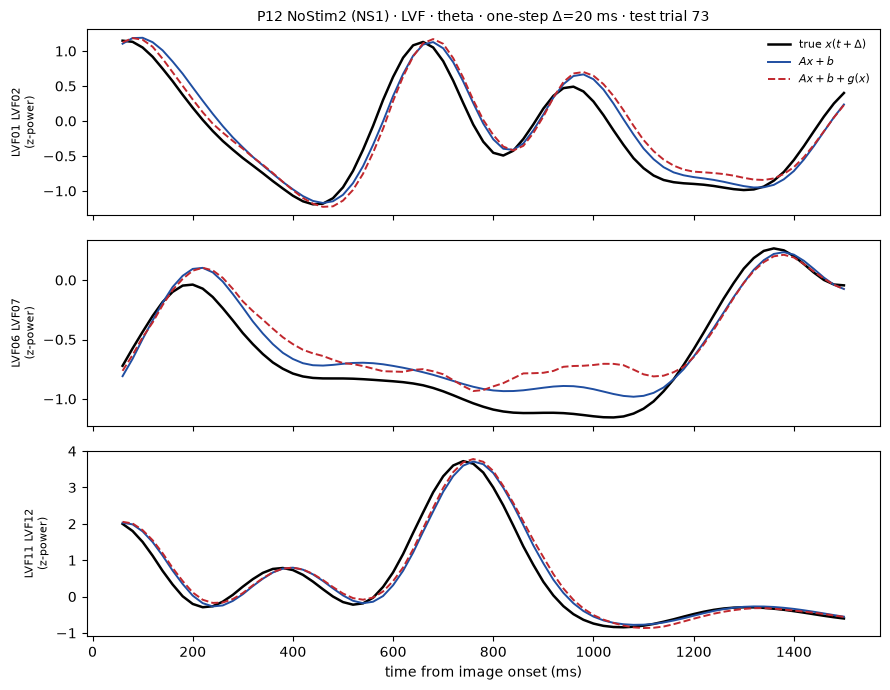

In [13]:
# ---------- POC part 2: horizon mini-sweep + trajectory figure ----------
# NOTE: with a 20-ms token stride, only multiples of 20 ms are realizable
# (spec's 10/50 ms horizons are not on the token grid; recorded as a deviation).
poc_horizons = [20, 40, 100, 200]
rows = []
models_at_h = {}
for h_ms in poc_horizons:
    hs = h_ms // TOKEN_STRIDE_MS
    Xtr_h, Ytr_h = make_pairs(z_r[tr], hs)
    Xva_h, Yva_h = make_pairs(z_r[va], hs)
    Xte_h, Yte_h = make_pairs(z_r[te], hs)
    A_h, b_h, lam_h = fit_ridge(Xtr_h, Ytr_h, Xva_h, Yva_h)
    R_tr = Ytr_h - ridge_predict(A_h, b_h, Xtr_h)
    R_va = Yva_h - ridge_predict(A_h, b_h, Xva_h)
    g_h = fit_residual_mlp(Xtr_h, R_tr, Xva_h, R_va)
    p_lin = ridge_predict(A_h, b_h, Xte_h)
    p_res = p_lin + mlp_predict(g_h, Xte_h)
    models_at_h[h_ms] = (A_h, b_h, g_h)
    for name, p in [("persistence", Xte_h), ("Ax+b", p_lin), ("Ax+b+g(x)", p_res)]:
        rows.append({"horizon_ms": h_ms, "model": name, **eval_all(Yte_h, p)})

poc_sweep = pd.DataFrame(rows)
display(poc_sweep.pivot(index="horizon_ms", columns="model", values="R2").round(4))

# ---------- Trajectory figure: one test trial, Δ=20 ms one-step predictions ----------
hs = 1
trial = te[0]
Xp, Yp = z_r[trial, :-hs, :], z_r[trial, hs:, :]
A20, b20, g20 = models_at_h[20]
p_lin = ridge_predict(A20, b20, Xp)
p_res = p_lin + mlp_predict(g20, Xp)
t_pred = token_t[hs:]

fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
for ax, ch in zip(axes, [0, 5, 10]):
    ax.plot(t_pred, Yp[:, ch], color=COLOR_TRUE, lw=1.8, label="true $x(t+\\Delta)$")
    ax.plot(t_pred, p_lin[:, ch], color=COLOR_LINEAR, lw=1.4, label="$Ax+b$")
    ax.plot(t_pred, p_res[:, ch], color=COLOR_RESIDUAL, lw=1.4, ls="--", label="$Ax+b+g(x)$")
    ax.set_ylabel(f"{ch_tbl.loc[clean_idx[region_mask_in_clean], 'pair_name'].iloc[ch]}\n(z-power)", fontsize=8)
axes[0].legend(loc="upper right", fontsize=8, frameon=False)
axes[0].set_title(f"P12 NoStim2 (NS1) · {POC_LEAD} · theta · one-step Δ=20 ms · test trial {trial}", fontsize=10)
axes[-1].set_xlabel("time from image onset (ms)")
fig.tight_layout()
fig.savefig(FIG_DIR / "poc_trajectory_P12_LVF_theta.png", dpi=200)
plt.show()


## 6. Horizon sweep (STEP 7, Analysis 3)

Δ ∈ {10, 20, 50, 100, 200} ms × {persistence, $Ax$, $Ax+\hat{w}$} × patients → `results/horizon_metrics.csv`. No monotonicity forced.

In [ ]:
# TODO: horizon sweep.

## 7. OOD: drug-state shift (STEPS 10-11, Analyses 4 + control)

Train placebo → frozen model → test held-out placebo (ID) vs scopolamine (OOD). Then the symmetric reverse (train scopolamine). Report $R^2_{ID} - R^2_{OOD}$ and residual-energy change → `results/ood_metrics.csv`.

In [ ]:
# TODO: OOD analysis (frozen model, both directions). Secondary: FR<->AR task transfer (spec §16).

## 8. Robustness & controls (STEPS 12, 14; spec §20)

Frequency bands (all 5) · temporal shuffle (should collapse) · trial shuffle (should strongly decrease) · electrode-count subsampling · patient-wise leave-one-out on the central claim.

In [ ]:
# TODO: shuffle controls + band robustness.

## 9. Cross-region "layer" mapping (STEP 13, Analysis 5)

Temporal cortex → entorhinal → hippocampus; lags δ ∈ {0, 10, 20, 50, 100} ms (selected on training data, all reported). Compare recurrent-only $R_l x^{(l+1)}_t$ vs source+recurrent $A_l x^{(l)}_t + R_l x^{(l+1)}_t$ → `results/layer_metrics.csv`.

In [ ]:
# TODO: cross-region models (only where simultaneous coverage exists; never fabricate layers).

## 10. Matrix diagnostics (spec §18)

Eigenvalue spectrum (complex plane), spectral radius, singular values, effective rank, condition number of each fitted $A$.

In [ ]:
# TODO: A-matrix diagnostics.

## 11. Patient-level statistics (STEP 15, spec §19)

One summary metric per patient per comparison → paired statistics across patients (linear vs linear+residual; ID vs OOD). Individual patient dots in all plots.

In [ ]:
# TODO: paired stats (Wilcoxon / paired t as appropriate).

## 12. Main four-panel figure (STEP 16, spec §22-24)

A: brain-as-network mapping · B: local linearization + representative real prediction (patient closest to median improvement — predefined, no cherry-picking) · C: horizon curves · D: OOD degradation. Colors: black = truth, blue = $Ax$, red = $Ax+\hat{w}$, identical across panels. Vector output.

In [ ]:
# TODO: figure assembly -> figures/main_figure.pdf/.png